# Battery Cycling

## Imports

In [1]:
import numpy as np
import pandas as pd

from redoxed.data_loading.data_loaders import LoaderFactory, BiologicLoader, CSVLoader
from redoxed.plots import GenericPlot, EfficiencyPlot
from redoxed import config
config.set_latex_mode(False)  

## Data Loading and Cycling Quantities
redoxED can automatically calculates efficiencies, charge capacities, currents, etc. from raw cycling data.

In [2]:
fpath=r"..\data\cell_cycling_1.mpr"
# csv_fpath = r"..\data\cell_cycling_1.csv" # load from csv

ECData_object = BiologicLoader().load_data(fpath=fpath)
# ECData_object = CSVLoader().load_data(fpath=csv_fpath) # load from csv (biologic naming assumed)

CyclingData_object = ECData_object.to_CyclingData()
CyclingData_object.set_area(0.0005)  # m2

If your format is not currently supported by redoxED, you can create a conversion function in See src\redoxed\data_loading\data_converters.py or pass the required data directly using:
```python
CyclingData(cycle_data=your_df, label=label)
```
or if quantities require calculation:
```python
CyclingData.from_V_t_dq_cycle(
        V_cell=V_cell, time=time, dq=dq, cycle_number=cycle_number, label=label
    )
```


## Plotting

,cycle_number,Q_pos_total,Q_neg_total,E_pos_total,E_neg_total,V_cell_avg_charge,V_cell_avg_discharge,I_cell_avg_charge,I_cell_avg_discharge,Q_charge,Q_discharge,E_charge,E_discharge,CE,VE,EE
0,1,1955.965837,-1894.611607,3001.952522,-2422.277744,1.534768,1.278511,0.399541,-0.400657,1955.965837,1894.611607,3001.952522,2422.277744,96.863226,83.303252,80.690075
1,2,2021.058131,-1956.948992,3105.103269,-2497.732782,1.536375,1.276344,0.399543,-0.400652,2021.058131,1956.948992,3105.103269,2497.732782,96.827942,83.075015,80.439604
2,3,2081.332347,-2012.183284,3197.546987,-2566.998903,1.536298,1.275731,0.399544,-0.400651,2081.332347,2012.183284,3197.546987,2566.998903,96.677654,83.039317,80.280256
3,4,2128.535821,-2058.938724,3270.327992,-2624.820324,1.536421,1.274844,0.399546,-0.400648,2128.535821,2058.938724,3270.327992,2624.820324,96.730283,82.974931,80.261684
4,5,2175.170293,-2099.145839,3342.598571,-2675.192629,1.536707,1.274423,0.399547,-0.400648,2175.170293,2099.145839,3342.598571,2675.192629,96.504896,82.932077,80.033321


,cycle_number,Q_pos_total,Q_neg_total,E_pos_total,E_neg_total,V_cell_avg_charge,V_cell_avg_discharge,I_cell_avg_charge,I_cell_avg_discharge,Q_charge,Q_discharge,E_charge,E_discharge,CE,VE,EE
0,1,2111.406603,-2048.065212,3137.814184,-2744.263923,1.486125,1.339933,0.399536,-0.400659,2111.406603,2048.065212,3137.814184,2744.263923,97.000038,90.162881,87.457821
1,2,2197.205299,-2128.713491,3263.084003,-2851.105879,1.485106,1.339360,0.399537,-0.400657,2197.205299,2128.713491,3263.084003,2851.105879,96.882776,90.186103,87.374578
2,3,2270.068065,-2197.356605,3371.477557,-2942.449364,1.485188,1.339089,0.399542,-0.400651,2270.068065,2197.356605,3371.477557,2942.449364,96.796948,90.162967,87.274772
3,4,2327.616444,-2251.219722,3458.639271,-3014.275905,1.485914,1.338956,0.399545,-0.400652,2327.616444,2251.219722,3458.639271,3014.275905,96.717813,90.109879,87.152075
4,5,2379.171005,-2299.615805,3536.610645,-3079.058157,1.486488,1.338948,0.399545,-0.400652,2379.171005,2299.615805,3536.610645,3079.058157,96.656180,90.074551,87.062401


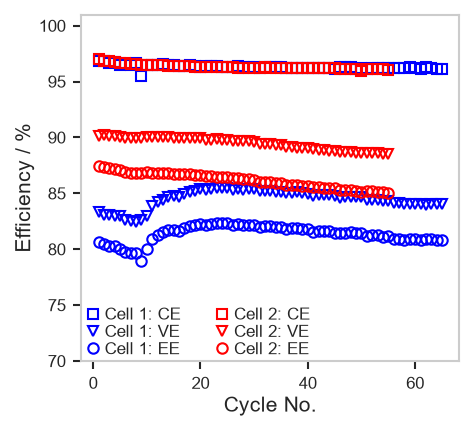

In [3]:
j_plot = False # note, only plots last j array seen as currently implemented. Move jplot into loop for multiple if desired.
cycling_plot_dict = {}

# add cell 1
fpath=r"..\data\cell_cycling_1.mpr"
ECData_object = BiologicLoader().load_data(fpath=fpath)
CyclingData_object = ECData_object.to_CyclingData() # load from csv requires columns named 
CyclingData_object.set_area(0.0005)  # m2
CyclingData_object.label = "Cell 1"

cycling_plot_dict[CyclingData_object.label] = {
        "data": CyclingData_object,
        "plot_kwargs": {"color": "blue", "label": CyclingData_object.label, "zorder": 4},
        "plot": True
    }

# add cell 2
fpath=r"..\data\cell_cycling_2.mpr"
ECData_object = BiologicLoader().load_data(fpath=fpath)
CyclingData_object = ECData_object.to_CyclingData() # load from csv requires columns named 
CyclingData_object.set_area(0.0005)  # m2
CyclingData_object.label = "Cell 2"

cycling_plot_dict[CyclingData_object.label] = {
        "data": CyclingData_object,
        "plot_kwargs": {"color": "red", "label": CyclingData_object.label, "zorder": 4},
        "plot": True
    }


#########################
## Create Cycling Plot ##
#########################
EfficiencyPlot_object = EfficiencyPlot(figsize=(3.25, 3), dpi = 150) 

for label, entry in cycling_plot_dict.items():
    if entry["plot"]:
        EfficiencyPlot_object.add_plot(entry["data"], **entry["plot_kwargs"], linestyle="", plot_CE=True, plot_VE=True, plot_EE=True)
        #EfficiencyPlot_object.add_plot(CyclingData_object, linestyle="", markersize=2, markerfacecolor='none', markeredgecolor='blue', color='blue')
    display(entry["data"].cycle_data.head(5)) # print first 5 rows of data
        #EfficiencyPlot_object.add_Q_discharge(x= entry["data"].cycle_data['cycle_number'], Q_discharge= entry["data"].cycle_data['Q_discharge'], Q_in_legend= True,)

# plot based on last CyclingData_object
if j_plot == True:
    EfficiencyPlot_object.add_j(x = CyclingData_object.cycle_data['cycle_number'], 
                                j = (1e3*CyclingData_object.cycle_data['I_cell_avg_charge'])/(1e4*CyclingData_object.area), 
                                linestyle="-", marker="", color='red', label="$j$")
    EfficiencyPlot_object.ax2.set_ylim(0, 101)

handles, labels = EfficiencyPlot_object.ax.get_legend_handles_labels()
custom_labels = labels

EfficiencyPlot_object.ax.set_ylim(70, 101)

# Create new legend with original handles (preserves colors, markers, etc.) but your labels
EfficiencyPlot_object.ax.legend(
    handles, 
    custom_labels,
    loc='best',
    ncol=2
)

display(EfficiencyPlot_object.fig)



### Other Plots
Other types of plots can be extracted from the base ECData dataframe or from CyclingData objects using the cycle_data and time_series dfs, respectively.

   flags  Ns        time/s  dq/mA.h  (Q-Qo)/mA.h  control/V/mA     Ewe/V  \
0      3   0  14268.294821      0.0          0.0           0.0  1.264950   
1      3   0  14269.294821      0.0          0.0           0.0  1.264454   
2      3   0  14270.294821      0.0          0.0           0.0  1.264072   

   I Range  Q charge/discharge/mA.h  half cycle  
0       14                      0.0           0  
1       14                      0.0           0  
2       14                      0.0           0  


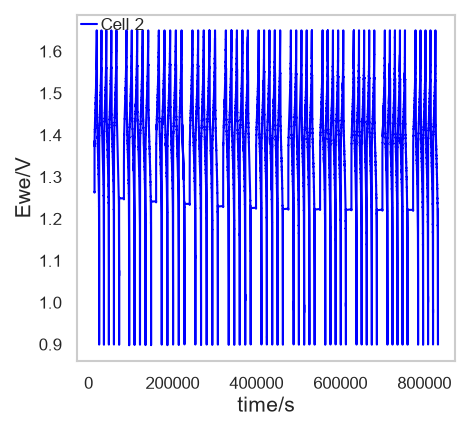

In [4]:
fpath=r"..\data\cell_cycling_2.mpr"
loader = LoaderFactory.get_loader(fpath)
data = loader.load_data(fpath=fpath)

#data.df.iloc[10:20]
print(data.df.head(3))
# GenericPlot_object = GenericPlot(x_col="time/s", y_col="Ewe/V", y2_col="control/V/mA")
GenericPlot_object = GenericPlot(x_col="time/s", y_col="Ewe/V", figsize=(3.25, 3), dpi = 150)
GenericPlot_object = GenericPlot(x_col="time/s", y_col="Ewe/V", figsize=(3.25, 3), dpi = 150)
GenericPlot_object.add_plot(data.df, linestyle = "-", marker = "", color1 = 'blue', color2='red', label = "Cell 2")
GenericPlot_object.ax.legend()
display(GenericPlot_object.fig)